#  Project Overview
Objective:

Analyze urban heat patterns in Surat using satellite-derived environmental features and build an AI/ML model to predict Urban Heat Islands and recommend cooling strategies.

# Import Libraries


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load Dataset

In [3]:
df = pd.read_csv("Surat_UHI_Complete.csv")

## Initial Exploration


Preview Dataset

In [4]:
df.head(5)

,latitude,longitude,year,LST,NDVI,NDBI,AirTemp_C,Humidity_pct,WindSpeed_ms,Population,LULC,GreenSpace,WaterOccurrence,WaterBody,LULC_Class
0,21.350709,72.747817,2015,43.239326,0.452801,-0.136430,28.565325,100.0,4.67343,1.781309,NaN,NaN,NaN,NaN,Unknown
1,21.350709,72.752309,2015,42.498980,0.481168,-0.164107,28.850704,100.0,3.98178,1.501480,NaN,NaN,NaN,NaN,Unknown
2,21.350709,72.756801,2015,40.148754,0.561344,-0.234726,28.850704,100.0,3.98178,1.270481,NaN,NaN,NaN,NaN,Unknown
3,21.350709,72.761292,2015,41.943897,0.469849,-0.150921,28.850704,100.0,3.98178,1.555159,NaN,NaN,NaN,NaN,Unknown
4,21.350709,72.765784,2015,43.231125,0.437470,-0.118096,28.850704,100.0,3.98178,1.272868,NaN,NaN,NaN,NaN,Unknown


Dataset Shape

In [5]:
print(df.shape)

(34884, 15)


Observation

*   34,884 observations
*   15 features




In [6]:
df.columns

Index(['latitude', 'longitude', 'year', 'LST', 'NDVI', 'NDBI', 'AirTemp_C',
       'Humidity_pct', 'WindSpeed_ms', 'Population', 'LULC', 'GreenSpace',
       'WaterOccurrence', 'WaterBody', 'LULC_Class'],
      dtype='object')

Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34884 entries, 0 to 34883
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   latitude         34884 non-null  float64
 1   longitude        34884 non-null  float64
 2   year             34884 non-null  int64  
 3   LST              34884 non-null  float64
 4   NDVI             34884 non-null  float64
 5   NDBI             34884 non-null  float64
 6   AirTemp_C        34884 non-null  float64
 7   Humidity_pct     34884 non-null  float64
 8   WindSpeed_ms     34884 non-null  float64
 9   Population       34767 non-null  float64
 10  LULC             33165 non-null  float64
 11  GreenSpace       33165 non-null  float64
 12  WaterOccurrence  1359 non-null   float64
 13  WaterBody        1359 non-null   float64
 14  LULC_Class       34884 non-null  object 
dtypes: float64(13), int64(1), object(1)
memory usage: 4.0+ MB


Observation

34,884 observations

15 features

# Data Quality Assessment

Missing Values

In [8]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
WaterBody,33525,96.104231
WaterOccurrence,33525,96.104231
LULC,1719,4.927761
GreenSpace,1719,4.927761
Population,117,0.335397
longitude,0,0.000000
latitude,0,0.000000
AirTemp_C,0,0.000000
NDBI,0,0.000000
NDVI,0,0.000000


Observation

1.Population contains only 0.33% missing values.

2.LULC and GreenSpace contain 4.93% missing values.

3.WaterBody and WaterOccurrence initially showed many missing values, which were confirmed to represent the absence of water information and were encoded appropriately.

4.Humidity contains no missing values but has only one unique value.

Missing Value Heatmap

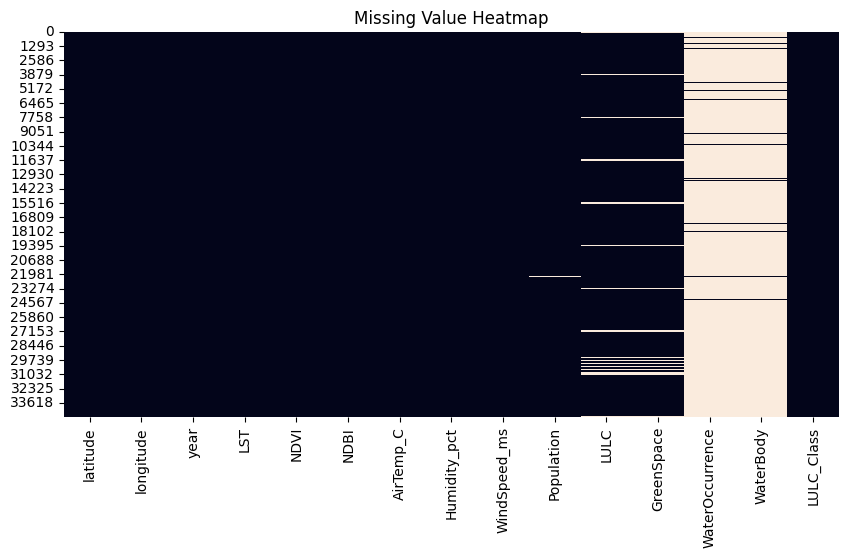

In [9]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

Observation

Visual inspection confirms missing values are concentrated in only a few features rather than being randomly distributed.

Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

Observation

No duplicate records were found.

Constant Features

In [11]:
for col in df.columns:
    print(col, df[col].nunique())

latitude 57
longitude 68
year 9
LST 21758
NDVI 34835
NDBI 34870
AirTemp_C 144
Humidity_pct 1
WindSpeed_ms 144
Population 23172
LULC 6
GreenSpace 2
WaterOccurrence 71
WaterBody 2
LULC_Class 7


Observation

Humidity contains only one unique value.

Decision

Remove the Humidity feature because it contributes no predictive information.

Statistical Summary

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,34884.0,21.224944,0.073896,21.099180,21.162062,21.224944,21.287826,21.350709
longitude,34884.0,72.898285,0.088161,72.747817,72.823051,72.898285,72.973519,73.048753
year,34884.0,2019.000000,2.582026,2015.000000,2017.000000,2019.000000,2021.000000,2023.000000
LST,34884.0,44.013673,3.117046,27.926825,42.233322,43.964461,45.940930,56.904797
NDVI,34884.0,0.366106,0.115240,-0.036326,0.284941,0.386652,0.452061,0.751380
NDBI,34884.0,-0.089644,0.076296,-0.443376,-0.143854,-0.090210,-0.028621,0.202684
AirTemp_C,34884.0,29.600581,0.371009,28.364708,29.290535,29.614239,29.848413,30.294878
Humidity_pct,34884.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000
WindSpeed_ms,34884.0,3.660110,0.383831,2.895773,3.367524,3.565287,3.963632,5.115328
Population,34767.0,28.272645,121.866129,0.443037,1.670520,3.814040,8.385751,1280.047500


Categorical Summary

In [13]:
for col in df.select_dtypes(include="object"):
    print(df[col].value_counts())

LULC_Class
Cropland       13347
Tree_Cover      9684
Built_Up        6750
Grassland       1989
Unknown         1719
Water           1062
Bare_Sparse      333
Name: count, dtype: int64


In [14]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

latitude: 57
longitude: 68
year: 9
LST: 21758
NDVI: 34835
NDBI: 34870
AirTemp_C: 144
Humidity_pct: 1
WindSpeed_ms: 144
Population: 23172
LULC: 6
GreenSpace: 2
WaterOccurrence: 71
WaterBody: 2
LULC_Class: 7


## Data Investigation

Why are LULC values missing?

In [15]:
print(df[df["LULC"].isna()]["LULC_Class"].value_counts())

LULC_Class
Unknown    1719
Name: count, dtype: int64


Finding

Every missing LULC value belongs to the Unknown land cover class.

Why is GreenSpace missing?

In [16]:
print(df[df["GreenSpace"].isna()]["LULC_Class"].value_counts())

LULC_Class
Unknown    1719
Name: count, dtype: int64


Finding

All missing GreenSpace values also belong to the Unknown land cover class.

Validate LULC mapping

In [17]:
pd.crosstab(df["LULC"], df["LULC_Class"])


LULC_Class,Bare_Sparse,Built_Up,Cropland,Grassland,Tree_Cover,Water
LULC,,,,,,
10.0,0,0,0,0,9684,0
30.0,0,0,0,1989,0,0
40.0,0,0,13347,0,0,0
50.0,0,6750,0,0,0,0
60.0,333,0,0,0,0,0
80.0,0,0,0,0,0,1062


Finding

Each numeric LULC code maps uniquely to one land-cover class.

Therefore,

LULC is redundant.

LULC_Class is retained because it is human-readable.

WaterBody distribution

In [18]:
print(df["WaterBody"].value_counts(dropna=False))

WaterBody
NaN    33525
0.0      738
1.0      621
Name: count, dtype: int64


Finding

Binary feature:

0 = No water

1 = Water

WaterOccurrence distribution

In [19]:
print(df["WaterOccurrence"].value_counts(dropna=False))

WaterOccurrence
NaN     33525
5.0        45
8.0        45
76.0       45
65.0       45
        ...  
60.0        9
78.0        9
51.0        9
17.0        9
9.0         9
Name: count, Length: 72, dtype: int64


Finding

Water occurrence ranges from 0–94%.

# Filling missing values


In [20]:
columns_to_drop = []
if 'Humidity_pct' in df.columns:
    columns_to_drop.append('Humidity_pct')
if 'LULC' in df.columns:
    columns_to_drop.append('LULC')

if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)

In [21]:
df["Population"] = df["Population"].fillna(df["Population"].median())

In [22]:
df["WaterBody"] = df["WaterBody"].fillna(0)

In [23]:
df["WaterOccurrence"] = df["WaterOccurrence"].fillna(0)

## Preprocessing Decisions

This is one of my favorite ways to present preprocessing because it tells the story of your reasoning.

| Issue           | Investigation                       | Decision            | Reason                       |
| --------------- | ----------------------------------- | ------------------- | ---------------------------- |
| Humidity        | Single unique value                 | Dropped             | No predictive information    |
| Population      | 117 missing values                  | Median imputation   | Small amount of missing data |
| LULC            | Redundant with LULC_Class           | Dropped             | Duplicate information        |
| LULC_Class      | Human-readable labels               | Kept                | Better interpretability      |
| GreenSpace      | Missing only for Unknown land cover | Retained as missing | Missing has semantic meaning |
| WaterBody       | Binary feature                      | Kept                | Valid feature                |
| WaterOccurrence | Continuous feature                  | Kept                | Valid feature                |


#Cleaned Dataset Summary

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34884 entries, 0 to 34883
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   latitude         34884 non-null  float64
 1   longitude        34884 non-null  float64
 2   year             34884 non-null  int64  
 3   LST              34884 non-null  float64
 4   NDVI             34884 non-null  float64
 5   NDBI             34884 non-null  float64
 6   AirTemp_C        34884 non-null  float64
 7   WindSpeed_ms     34884 non-null  float64
 8   Population       34884 non-null  float64
 9   GreenSpace       33165 non-null  float64
 10  WaterOccurrence  34884 non-null  float64
 11  WaterBody        34884 non-null  float64
 12  LULC_Class       34884 non-null  object 
dtypes: float64(11), int64(1), object(1)
memory usage: 3.5+ MB


In [25]:
df.isnull().sum()

,0
latitude,0
longitude,0
year,0
LST,0
NDVI,0
NDBI,0
AirTemp_C,0
WindSpeed_ms,0
Population,0
GreenSpace,1719


Remaining missing values exist only in GreenSpace and are associated with Unknown land-cover classes. These values are retained because they carry semantic meaning rather than representing random missingness.

# Exploratory Data Analysis

The objective of this analysis is to understand the spatial, temporal,
environmental, and urban factors associated with Land Surface Temperature
(LST) in Surat.

The analysis focuses on identifying heat patterns and examining the
relationships between surface temperature, vegetation, built-up intensity,
land cover, population, weather conditions, green spaces, and water presence.

## 1. Target Variable Analysis — Land Surface Temperature (LST)

Land Surface Temperature is the primary variable of interest in this study.
Understanding its distribution helps identify the overall thermal behavior
of the study area and detect possible extreme temperature observations.

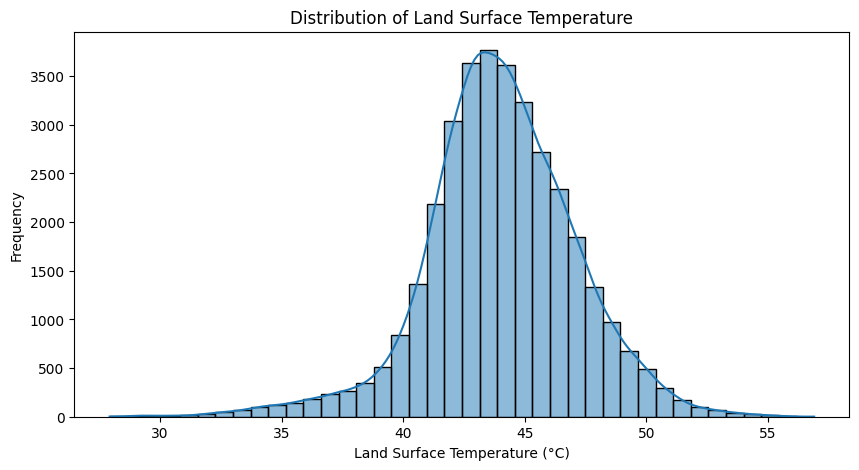

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="LST",
    bins=40,
    kde=True
)

plt.title("Distribution of Land Surface Temperature")
plt.xlabel("Land Surface Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

In [27]:
df["LST"].describe()

,LST
count,34884.000000
mean,44.013673
std,3.117046
min,27.926825
25%,42.233322
50%,43.964461
75%,45.940930
max,56.904797


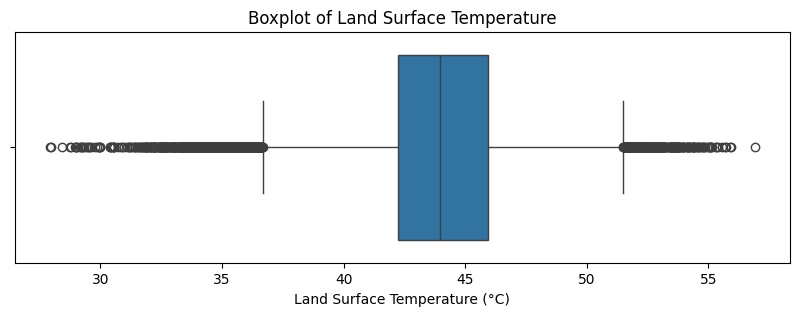

In [28]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="LST"
)

plt.title("Boxplot of Land Surface Temperature")
plt.xlabel("Land Surface Temperature (°C)")

plt.show()

Key Finding: The LST distribution is approximately bell-shaped and centered around 44°C, with the mean and median showing close agreement. Most observations fall within a relatively concentrated temperature range, while both low- and high-temperature extremes are present. Although the boxplot identifies several statistical outliers, these observations are retained for further investigation because they may represent genuine spatial differences associated with water bodies, vegetation, built-up regions, or bare surfaces rather than data errors.

#Vegetation and Built-Up Intensity vs LST

In [29]:
print("NDVI–LST correlation:", df["NDVI"].corr(df["LST"]))
print("NDBI–LST correlation:", df["NDBI"].corr(df["LST"]))

NDVI–LST correlation: -0.4681887726109425
NDBI–LST correlation: 0.6513333903236127


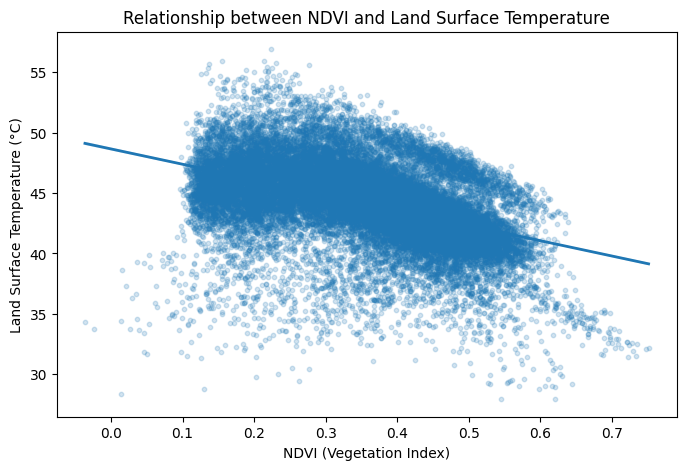

In [30]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="NDVI",
    y="LST",
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"linewidth": 2}
)

plt.title("Relationship between NDVI and Land Surface Temperature")
plt.xlabel("NDVI (Vegetation Index)")
plt.ylabel("Land Surface Temperature (°C)")
plt.show()

Key Finding: NDVI shows a moderate negative correlation with LST (r = −0.468). The overall downward trend indicates that locations with higher vegetation intensity tend to exhibit lower land surface temperatures. However, the dispersion of observations suggests that surface temperature is also influenced by additional environmental and urban factors.

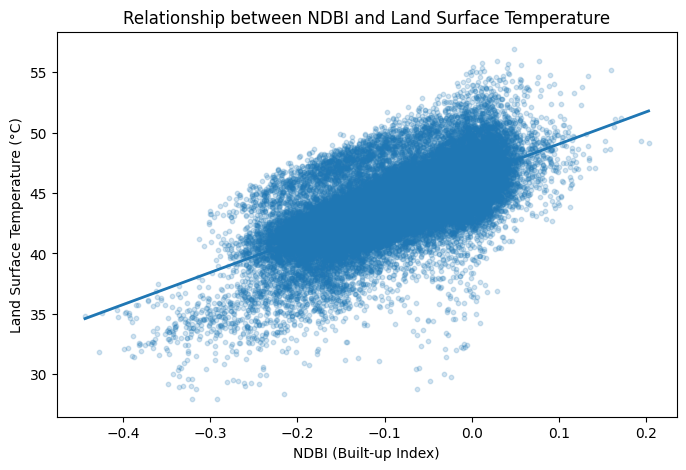

In [31]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="NDBI",
    y="LST",
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"linewidth": 2}
)

plt.title("Relationship between NDBI and Land Surface Temperature")
plt.xlabel("NDBI (Built-up Index)")
plt.ylabel("Land Surface Temperature (°C)")
plt.show()

Key Finding: NDBI exhibits a moderately strong positive correlation with LST (r = 0.651). The positive trend suggests that areas with greater built-up intensity tend to experience higher surface temperatures. Among the two indices examined, NDBI shows a stronger linear association with LST than NDVI.

## 3. Meteorological and Human Factors vs LST

This section examines the relationships between Land Surface Temperature
and selected meteorological and human-related variables, including air
temperature, wind speed, and population.

In [32]:
print("Air Temperature–LST correlation:",
      df["AirTemp_C"].corr(df["LST"]))

print("Wind Speed–LST correlation:",
      df["WindSpeed_ms"].corr(df["LST"]))

print("Population–LST correlation:",
      df["Population"].corr(df["LST"]))

Air Temperature–LST correlation: -0.016871712077006846
Wind Speed–LST correlation: -0.06466367775937717
Population–LST correlation: 0.007961909697234561


Key Finding: Air temperature, wind speed, and population show negligible overall linear correlations with LST, with Pearson correlation coefficients of −0.017, −0.065, and 0.008, respectively. These results indicate that none of the three variables has a strong direct linear association with surface temperature across the complete dataset. However, they are retained for later multivariate and temporal analysis because weak marginal correlation does not necessarily imply low predictive value when variables interact with spatial, environmental, or time-dependent factors.

Land Cover vs LST

In [33]:
lulc_lst = (
    df.groupby("LULC_Class")["LST"]
      .agg(["mean", "median", "std", "count"])
      .sort_values("mean", ascending=False)
)

lulc_lst

,mean,median,std,count
LULC_Class,,,,
Bare_Sparse,45.694820,45.862316,3.070729,333
Built_Up,45.688936,45.642080,2.624100,6750
Grassland,45.087078,44.805008,2.688789,1989
Unknown,43.903128,43.921448,3.672708,1719
Cropland,43.733236,43.639236,3.015849,13347
Tree_Cover,43.550915,43.320560,2.507679,9684
Water,38.751457,38.023657,3.730563,1062


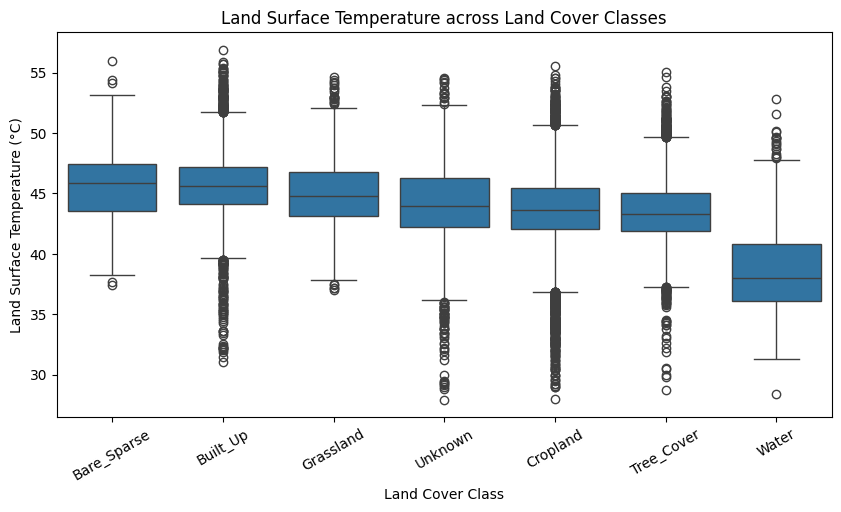

In [34]:
plt.figure(figsize=(10, 5))

order = (
    df.groupby("LULC_Class")["LST"]
      .median()
      .sort_values(ascending=False)
      .index
)

sns.boxplot(
    data=df,
    x="LULC_Class",
    y="LST",
    order=order
)

plt.title("Land Surface Temperature across Land Cover Classes")
plt.xlabel("Land Cover Class")
plt.ylabel("Land Surface Temperature (°C)")
plt.xticks(rotation=30)

plt.show()

Key Finding: Land Surface Temperature varies substantially across land-cover classes. Bare sparse and built-up areas exhibit the highest mean LST values, at approximately 45.69°C, while water bodies show the lowest mean temperature at approximately 38.75°C. Tree-covered and cropland areas also exhibit lower average surface temperatures than built-up regions. These patterns indicate a strong association between land-cover characteristics and urban surface heat, supporting the inclusion of vegetation and water-related features in subsequent mitigation analysis.

Green Space and Water Cooling Analysis

In [35]:
green_summary = (
    df.groupby("GreenSpace")["LST"]
      .agg(["mean", "median", "std", "count"])
)

water_summary = (
    df.groupby("WaterBody")["LST"]
      .agg(["mean", "median", "std", "count"])
)

print("Green Space Summary:")
display(green_summary)

print("Water Body Summary:")
display(water_summary)

Green Space Summary:


,mean,median,std,count
GreenSpace,,,,
0.0,44.131688,44.230495,3.312401,21492
1.0,43.812666,43.533504,2.604192,11673


Water Body Summary:


,mean,median,std,count
WaterBody,,,,
0.0,44.130047,44.020855,2.998179,34263
1.0,37.592863,37.288780,2.803399,621


In [36]:
green_gap = (
    df.loc[df["GreenSpace"] == 0, "LST"].mean()
    - df.loc[df["GreenSpace"] == 1, "LST"].mean()
)

water_gap = (
    df.loc[df["WaterBody"] == 0, "LST"].mean()
    - df.loc[df["WaterBody"] == 1, "LST"].mean()
)

print(f"Mean LST difference: Non-green minus green = {green_gap:.2f} °C")
print(f"Mean LST difference: Non-water minus water = {water_gap:.2f} °C")

Mean LST difference: Non-green minus green = 0.32 °C
Mean LST difference: Non-water minus water = 6.54 °C


Key Finding: Green-space locations show a slightly lower mean LST than non-green locations, with an average difference of approximately 0.32°C. The relatively small difference suggests that binary green-space presence alone may not fully capture the relationship between vegetation and surface temperature. This is consistent with the stronger NDVI–LST relationship observed earlier, indicating that vegetation intensity may be more informative than simple green-space presence.

Water-body locations exhibit substantially lower surface temperatures than non-water locations. The observed mean difference of approximately 6.54°C indicates a strong association between water presence and lower LST in the study area. This supports further investigation of blue infrastructure and proximity-to-water effects in the cooling-strategy analysis.

##  Temporal Analysis

This section examines year-wise changes in Land Surface Temperature (LST),
vegetation intensity (NDVI), and built-up intensity (NDBI) from 2015 to 2023.

The objective is to identify temporal patterns in urban surface heat and
investigate whether changes in vegetation and built-up characteristics
coincide with changes in surface temperature.

In [37]:
yearly_trends = (
    df.groupby("year")
      .agg(
          Mean_LST=("LST", "mean"),
          Median_LST=("LST", "median"),
          Mean_NDVI=("NDVI", "mean"),
          Mean_NDBI=("NDBI", "mean")
      )
      .reset_index()
)

yearly_trends

,year,Mean_LST,Median_LST,Mean_NDVI,Mean_NDBI
0,2015,43.551156,43.501830,0.378988,-0.109143
1,2016,43.156732,43.459018,0.369147,-0.084833
2,2017,43.248898,43.420140,0.359776,-0.088233
3,2018,45.168192,45.186971,0.356602,-0.082106
4,2019,45.916814,46.017550,0.338058,-0.074559
5,2020,46.533755,47.177112,0.392058,-0.111536
6,2021,42.684413,42.834519,0.376740,-0.077871
7,2022,42.368607,42.476520,0.358232,-0.085333
8,2023,43.494488,43.646868,0.365350,-0.093179


Year-wise mean LST

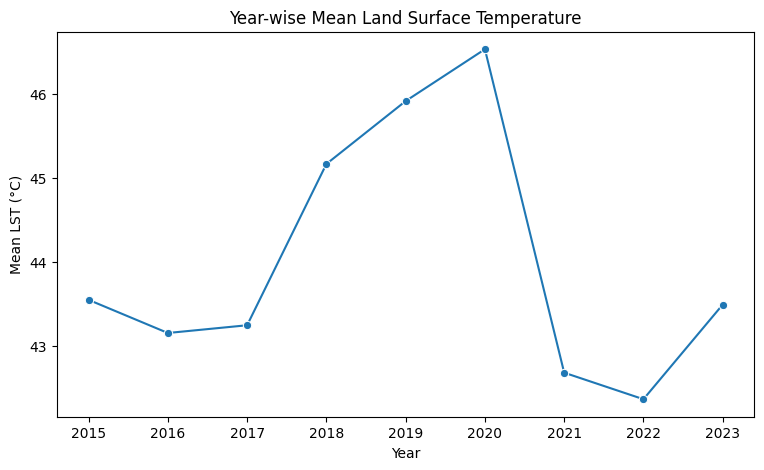

In [38]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=yearly_trends,
    x="year",
    y="Mean_LST",
    marker="o"
)

plt.title("Year-wise Mean Land Surface Temperature")
plt.xlabel("Year")
plt.ylabel("Mean LST (°C)")
plt.xticks(yearly_trends["year"])

plt.show()

Key Finding: The temporal analysis reveals substantial interannual variability in LST rather than a continuous warming trend. Mean LST remained relatively stable from 2015 to 2017, increased markedly between 2018 and 2020, and reached its maximum annual mean of approximately 46.53°C in 2020. A sharp decrease occurred in 2021 and 2022, followed by a partial rebound in 2023. Since each year contains an equal number of observations, these differences are not caused by unequal annual sample counts. Further spatial and environmental analysis is required to understand the observed temporal fluctuations.

Year-wise NDVI

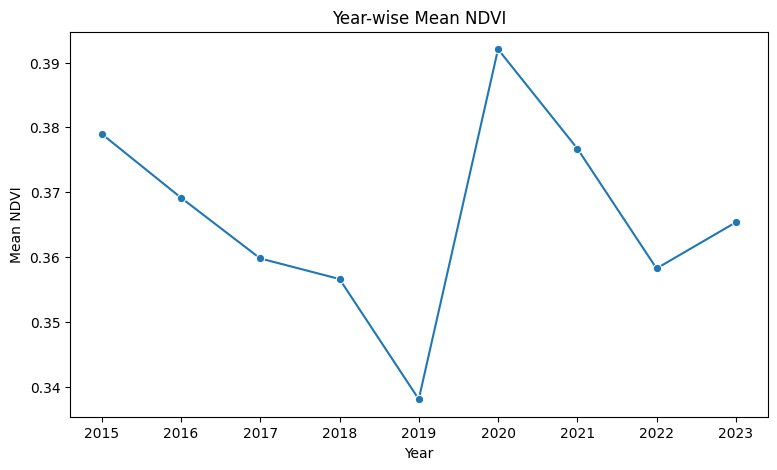

In [39]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=yearly_trends,
    x="year",
    y="Mean_NDVI",
    marker="o"
)

plt.title("Year-wise Mean NDVI")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.xticks(yearly_trends["year"])

plt.show()

Key Finding: Mean NDVI declined gradually between 2015 and 2019, followed by a sharp increase in 2020. Vegetation intensity subsequently decreased through 2022 and showed a modest recovery in 2023. The temporal relationship between annual mean NDVI and LST is not straightforward, suggesting that spatial variation and additional environmental factors should be considered alongside city-wide yearly averages.

Year-wise NDBI

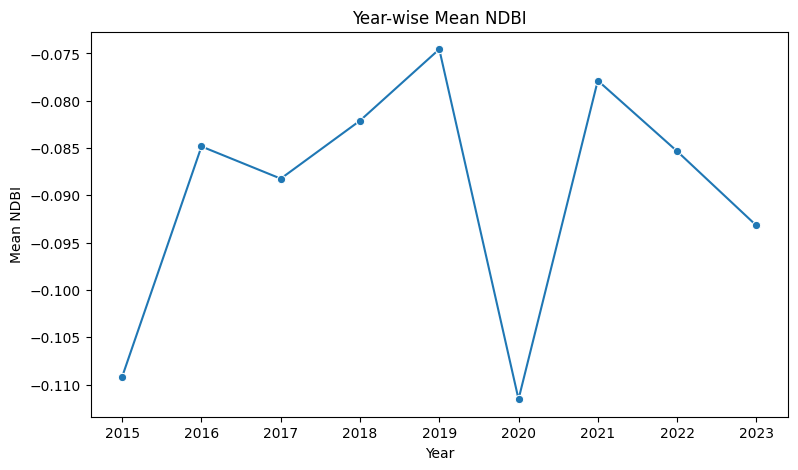

In [40]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=yearly_trends,
    x="year",
    y="Mean_NDBI",
    marker="o"
)

plt.title("Year-wise Mean NDBI")
plt.xlabel("Year")
plt.ylabel("Mean NDBI")
plt.xticks(yearly_trends["year"])

plt.show()

Key Finding: Mean NDBI exhibits considerable year-to-year variation and does not follow a consistent monotonic trend across the study period. The irregular pattern indicates that annual city-wide averages may not fully represent localized changes in built-up intensity. Spatial analysis is therefore necessary to identify where heat and built-up conditions are concentrated.

In [41]:
df.groupby("year").size()

,0
year,
2015,3876
2016,3876
2017,3876
2018,3876
2019,3876
2020,3876
2021,3876
2022,3876
2023,3876


Distribution of LST by Year

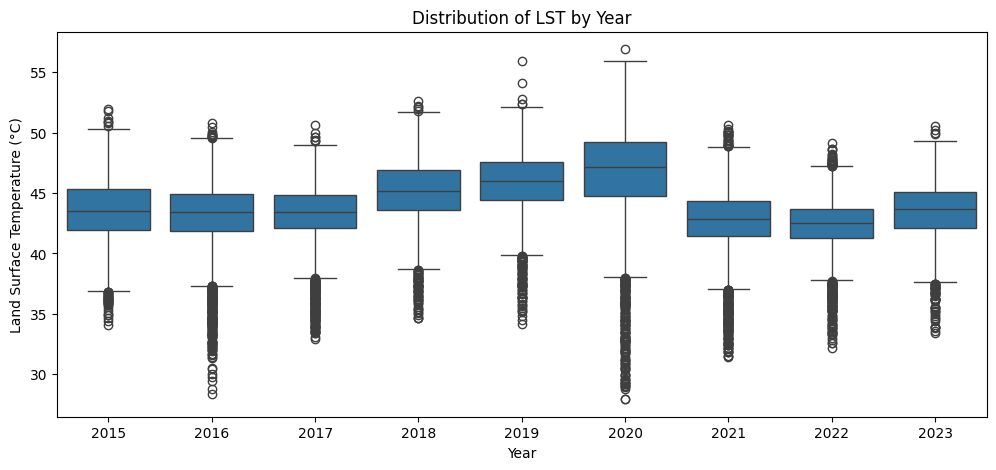

In [42]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="year",
    y="LST"
)

plt.title("Distribution of LST by Year")
plt.xlabel("Year")
plt.ylabel("Land Surface Temperature (°C)")

plt.show()

Key Finding: The year-wise LST distributions confirm substantial temporal shifts across the study period. The increase observed from 2018 to 2020 is reflected not only in annual mean values but also in upward shifts of the median and interquartile range, indicating broadly higher surface temperatures across the spatial observations. Similarly, the decline in 2021 and 2022 represents a general downward shift in the temperature distribution rather than being driven solely by extreme observations. The results demonstrate considerable interannual variability in surface thermal conditions.

Interpretation Note: These temporal differences should not automatically be interpreted as a long-term climate trend, since annual LST may also be influenced by satellite acquisition timing, seasonal conditions, rainfall, cloud filtering, and other year-specific environmental factors.

## Spatial Analysis and Heat Hotspot Detection

This section examines the spatial distribution of Land Surface Temperature
across the study area. The objective is to identify persistent heat patterns,
locate high-temperature zones, and examine the environmental characteristics
associated with hotter and cooler locations.

In [43]:
spatial_lst = (
    df.groupby(["latitude", "longitude"])
      .agg(
          Mean_LST=("LST", "mean"),
          Mean_NDVI=("NDVI", "mean"),
          Mean_NDBI=("NDBI", "mean")
      )
      .reset_index()
)

spatial_lst.head()

,latitude,longitude,Mean_LST,Mean_NDVI,Mean_NDBI
0,21.09918,72.747817,46.156770,0.160837,0.056652
1,21.09918,72.752309,49.196959,0.174577,0.072402
2,21.09918,72.756801,49.560584,0.177174,0.074246
3,21.09918,72.761292,49.612186,0.178770,0.077091
4,21.09918,72.765784,49.139584,0.183539,0.076690


In [44]:
spatial_lst.shape

(3876, 5)

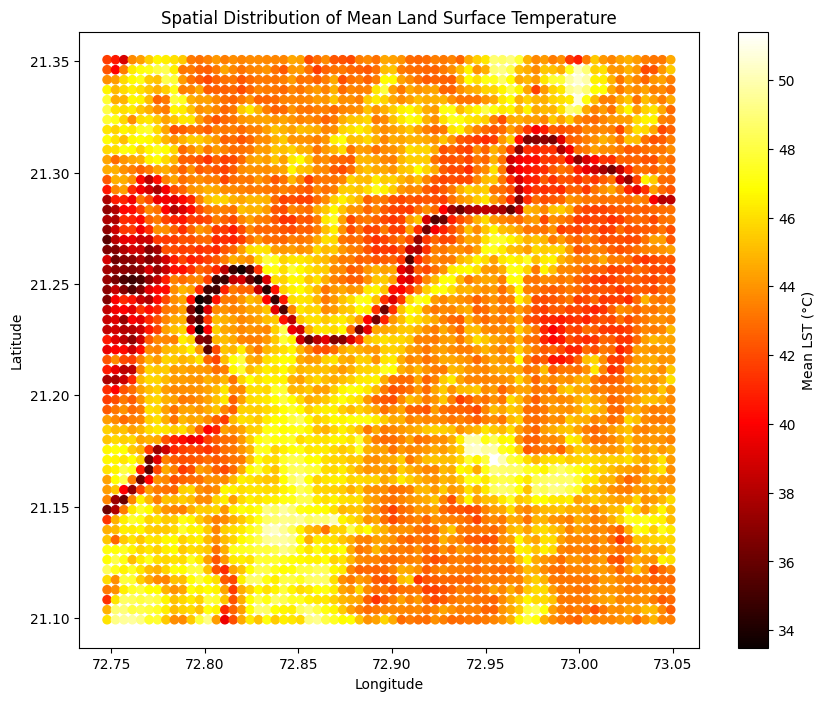

In [45]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    spatial_lst["longitude"],
    spatial_lst["latitude"],
    c=spatial_lst["Mean_LST"],
    cmap="hot",
    s=35
)

plt.colorbar(scatter, label="Mean LST (°C)")

plt.title("Spatial Distribution of Mean Land Surface Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [46]:
hotspot_threshold = spatial_lst["Mean_LST"].quantile(0.90)

print("Hotspot threshold:", hotspot_threshold)

Hotspot threshold: 46.72880283333333


In [47]:
spatial_lst["Hotspot"] = (
    spatial_lst["Mean_LST"] >= hotspot_threshold
).astype(int)

spatial_lst["Hotspot"].value_counts()

,count
Hotspot,
0,3488
1,388


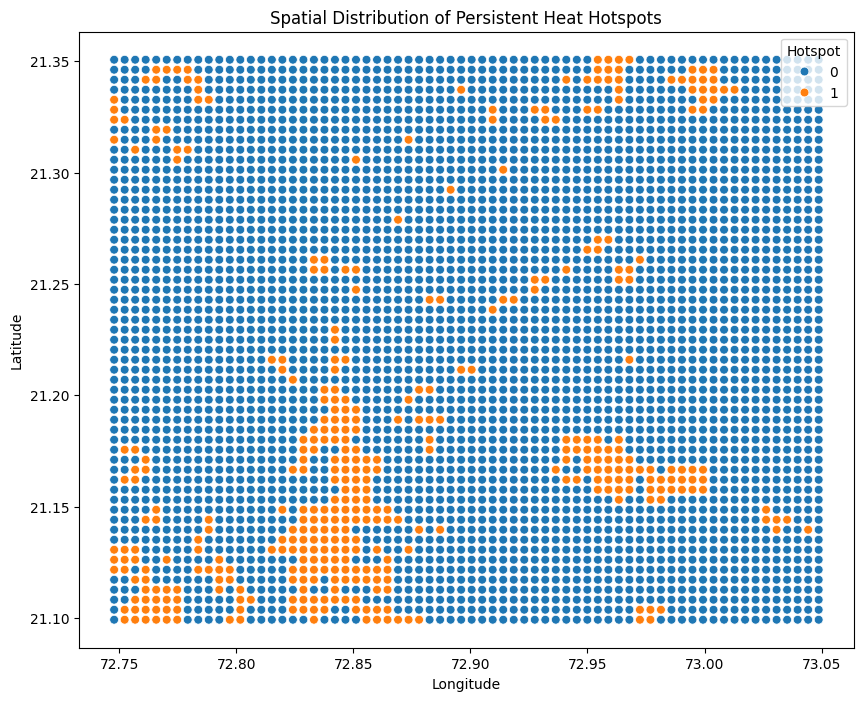

In [48]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=spatial_lst,
    x="longitude",
    y="latitude",
    hue="Hotspot",
    s=40
)

plt.title("Spatial Distribution of Persistent Heat Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Key Finding: Spatial aggregation across the nine-year study period identified 3,876 unique locations. Persistent heat hotspots were defined as locations whose long-term mean LST exceeded the 90th percentile threshold of approximately 46.73°C. This classified 388 locations as persistent hotspots and 3,488 as non-hotspots. The hotspot map reveals spatial clustering rather than a random distribution of high-temperature locations, indicating that urban heat exposure is geographically uneven across the study area.

In [49]:
hotspot_comparison = (
    spatial_lst.groupby("Hotspot")
    .agg(
        Mean_LST=("Mean_LST", "mean"),
        Mean_NDVI=("Mean_NDVI", "mean"),
        Mean_NDBI=("Mean_NDBI", "mean"),
        Locations=("Hotspot", "size")
    )
)

hotspot_comparison

,Mean_LST,Mean_NDVI,Mean_NDBI,Locations
Hotspot,,,,
0,43.595272,0.380863,-0.100981,3488
1,47.774967,0.233446,0.012275,388


In [50]:
ndvi_difference = (
    hotspot_comparison.loc[1, "Mean_NDVI"]
    - hotspot_comparison.loc[0, "Mean_NDVI"]
)

ndbi_difference = (
    hotspot_comparison.loc[1, "Mean_NDBI"]
    - hotspot_comparison.loc[0, "Mean_NDBI"]
)

print(f"Hotspot minus non-hotspot NDVI difference: {ndvi_difference:.3f}")
print(f"Hotspot minus non-hotspot NDBI difference: {ndbi_difference:.3f}")

Hotspot minus non-hotspot NDVI difference: -0.147
Hotspot minus non-hotspot NDBI difference: 0.113


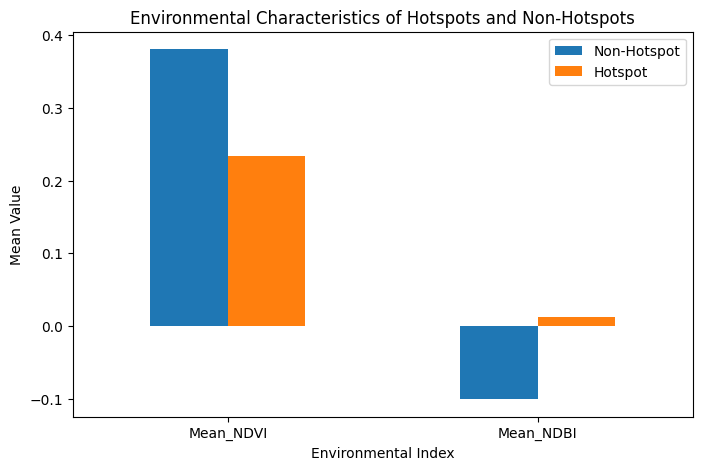

In [51]:
comparison_plot = hotspot_comparison[
    ["Mean_NDVI", "Mean_NDBI"]
].T

comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Environmental Characteristics of Hotspots and Non-Hotspots")
plt.xlabel("Environmental Index")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(["Non-Hotspot", "Hotspot"])

plt.show()

Key Finding: Persistent heat hotspots exhibit distinctly different environmental characteristics from non-hotspot locations. Hotspot locations have a mean LST of approximately 47.77°C compared with 43.60°C for non-hotspot locations. They also show substantially lower mean NDVI values, with a difference of −0.147, and higher mean NDBI values, with a difference of +0.113. These results indicate that persistent hotspots in the study area are associated with lower vegetation intensity and greater built-up intensity.

Final correlation analysis

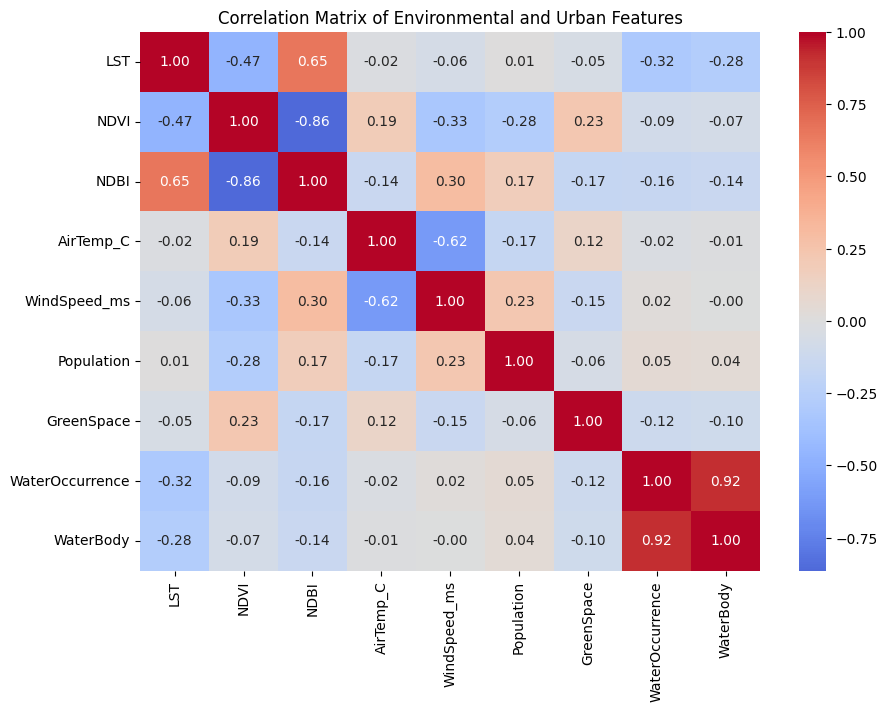

In [52]:
corr_features = [
    "LST",
    "NDVI",
    "NDBI",
    "AirTemp_C",
    "WindSpeed_ms",
    "Population",
    "GreenSpace",
    "WaterOccurrence",
    "WaterBody"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Environmental and Urban Features")
plt.show()

Key Finding: The correlation analysis shows that NDBI has the strongest positive linear relationship with LST (r = 0.65), while NDVI shows a moderate negative relationship (r = -0.47). WaterOccurrence (r = -0.32) and WaterBody (r = -0.28) are also negatively associated with LST, supporting the observed cooling pattern around water-related locations. Air temperature, wind speed, population, and the binary GreenSpace indicator show weak direct linear relationships with LST.

#EDA Conclusion

 The exploratory analysis identified clear environmental and spatial patterns associated with urban surface heat. NDBI showed the strongest positive relationship with LST, while NDVI exhibited a moderate negative relationship, indicating that hotter locations tend to be more built-up and less vegetated. Land-cover analysis showed that built-up and bare sparse surfaces have the highest average temperatures, whereas water bodies are substantially cooler. Persistent relative hotspots were spatially clustered and were characterized by lower mean NDVI and higher mean NDBI than non-hotspot locations. Temporal analysis revealed substantial year-to-year variability rather than a continuous monotonic warming trend. Overall, the findings support the development of an ML-based system for predicting surface temperature and identifying location-specific cooling priorities.

#  Machine Learning Pipeline

The exploratory data analysis provided valuable insights into the relationships between land surface temperature and various environmental, meteorological, and land-cover features.

In this phase, the cleaned dataset is prepared for machine learning. The objective is to develop a regression model that predicts Land Surface Temperature (LST) using spatial, environmental, and urban characteristics. The predicted LST can subsequently be used to identify urban heat hotspots and support data-driven cooling strategy recommendations.

##  Feature Selection

Based on the findings from the exploratory data analysis, the following features are selected for model development.

### Target Variable
- LST

### Input Features
- Latitude
- Longitude
- Year
- NDVI
- NDBI
- AirTemp_C
- WindSpeed_ms
- Population
- GreenSpace
- WaterOccurrence
- WaterBody
- LULC_Class

The numeric LULC feature is excluded because it provides the same information as the categorical LULC_Class feature and is therefore redundant.

##  Data Preparation

Before training machine learning models, the cleaned dataset is prepared by removing redundant features, handling the remaining missing values, and separating the input features from the target variable.

The numeric LULC feature is removed because it is redundant with the categorical LULC_Class feature. The GreenSpace feature contains missing values only for observations with unknown land cover. These missing values are represented using -1 to distinguish unknown information from the absence of green space.

Create a copy of the cleaned dataset

In [53]:
# Create a copy of the cleaned dataset
df_ml = df.copy()

Remove redundant feature

In [54]:
# Remove redundant feature
df_ml.drop(columns=["LULC"], inplace=True, errors="ignore")

Handle remaining missing values

In [55]:
# Replace missing GreenSpace values with -1
df_ml["GreenSpace"] = df_ml["GreenSpace"].fillna(-1)

Verify missing values

In [56]:
# Check for remaining missing values
df_ml.isnull().sum()

,0
latitude,0
longitude,0
year,0
LST,0
NDVI,0
NDBI,0
AirTemp_C,0
WindSpeed_ms,0
Population,0
GreenSpace,0


Verify dataset shape

In [57]:
print("Dataset Shape:", df_ml.shape)
df_ml.head()

Dataset Shape: (34884, 13)


,latitude,longitude,year,LST,NDVI,NDBI,AirTemp_C,WindSpeed_ms,Population,GreenSpace,WaterOccurrence,WaterBody,LULC_Class
0,21.350709,72.747817,2015,43.239326,0.452801,-0.136430,28.565325,4.67343,1.781309,-1.0,0.0,0.0,Unknown
1,21.350709,72.752309,2015,42.498980,0.481168,-0.164107,28.850704,3.98178,1.501480,-1.0,0.0,0.0,Unknown
2,21.350709,72.756801,2015,40.148754,0.561344,-0.234726,28.850704,3.98178,1.270481,-1.0,0.0,0.0,Unknown
3,21.350709,72.761292,2015,41.943897,0.469849,-0.150921,28.850704,3.98178,1.555159,-1.0,0.0,0.0,Unknown
4,21.350709,72.765784,2015,43.231125,0.437470,-0.118096,28.850704,3.98178,1.272868,-1.0,0.0,0.0,Unknown


##  Feature and Target Definition

In supervised machine learning, the dataset is divided into input features (`X`) and the target variable (`y`).

The target variable is **Land Surface Temperature (LST)**, while the remaining selected features are used as predictors. Separating the features and target is an essential step before applying preprocessing techniques and training machine learning models.

Define Input Features and Target

In [58]:
# Define input features and target variable
X = df_ml.drop(columns=["LST"])
y = df_ml["LST"]

Verify Shapes

In [59]:
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (34884, 12)
Target Vector Shape: (34884,)


Identify Feature Types

In [60]:
# Numerical features
numerical_features = [
    "Latitude",
    "Longitude",
    "Year",
    "NDVI",
    "NDBI",
    "AirTemp_C",
    "WindSpeed_ms",
    "Population",
    "GreenSpace",
    "WaterOccurrence",
    "WaterBody"
]

# Categorical features
categorical_features = [
    "LULC_Class"
]

Display Feature Information

In [61]:
print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Latitude', 'Longitude', 'Year', 'NDVI', 'NDBI', 'AirTemp_C', 'WindSpeed_ms', 'Population', 'GreenSpace', 'WaterOccurrence', 'WaterBody']

Categorical Features:
['LULC_Class']


Verify Dataset

In [62]:
X.head()

,latitude,longitude,year,NDVI,NDBI,AirTemp_C,WindSpeed_ms,Population,GreenSpace,WaterOccurrence,WaterBody,LULC_Class
0,21.350709,72.747817,2015,0.452801,-0.136430,28.565325,4.67343,1.781309,-1.0,0.0,0.0,Unknown
1,21.350709,72.752309,2015,0.481168,-0.164107,28.850704,3.98178,1.501480,-1.0,0.0,0.0,Unknown
2,21.350709,72.756801,2015,0.561344,-0.234726,28.850704,3.98178,1.270481,-1.0,0.0,0.0,Unknown
3,21.350709,72.761292,2015,0.469849,-0.150921,28.850704,3.98178,1.555159,-1.0,0.0,0.0,Unknown
4,21.350709,72.765784,2015,0.437470,-0.118096,28.850704,3.98178,1.272868,-1.0,0.0,0.0,Unknown


##  Data Preprocessing Pipeline

Before training machine learning models, the input features must be transformed into a suitable format.

The preprocessing pipeline performs the following operations:

- Numerical features are passed through without scaling since tree-based models (e.g., Random Forest and XGBoost) are not sensitive to feature scaling.
- The categorical feature (`LULC_Class`) is converted into numerical format using One-Hot Encoding.
- A `ColumnTransformer` is used to apply different preprocessing steps to different feature types in a single pipeline.

This approach ensures consistent preprocessing during both model training and prediction while reducing the risk of data leakage.

Import Required Libraries

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [64]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

Explanation

cat → applies One-Hot Encoding to LULC_Class.

handle_unknown="ignore" → prevents errors if unseen categories appear in future data.

remainder="passthrough" → keeps all numerical features unchanged.

Fit and Transform the Features

In [65]:
# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

Verify the Processed Data

In [66]:
print("Processed Feature Matrix Shape:", X_processed.shape)

Processed Feature Matrix Shape: (34884, 18)


Reviewing Encoded Feature Names

In [67]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['cat__LULC_Class_Bare_Sparse' 'cat__LULC_Class_Built_Up'
 'cat__LULC_Class_Cropland' 'cat__LULC_Class_Grassland'
 'cat__LULC_Class_Tree_Cover' 'cat__LULC_Class_Unknown'
 'cat__LULC_Class_Water' 'remainder__latitude' 'remainder__longitude'
 'remainder__year' 'remainder__NDVI' 'remainder__NDBI'
 'remainder__AirTemp_C' 'remainder__WindSpeed_ms' 'remainder__Population'
 'remainder__GreenSpace' 'remainder__WaterOccurrence'
 'remainder__WaterBody']


##  Train-Test Split

The dataset contains repeated observations for the same geographic locations across multiple years. A conventional random train-test split may place observations from the same location in both the training and testing sets, leading to spatial data leakage.

To obtain a more realistic evaluation, a group-based train-test split is performed using the geographic coordinates as grouping variables. This ensures that all observations from a given location are assigned exclusively to either the training or the testing set.

Import Library

In [72]:
from sklearn.model_selection import GroupShuffleSplit

Create Groups

In [74]:
groups = df_ml["latitude"].astype(str) + "_" + df_ml["longitude"].astype(str)

Perform the Split

In [75]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_processed, y, groups=groups))

X_train = X_processed[train_idx]
X_test = X_processed[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

Verify

In [76]:
print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 27900
Testing Samples : 6984


### Split Summary

A group-based train-test split was successfully performed using the unique geographic locations as grouping variables. This ensures that all observations from a particular location are assigned exclusively to either the training or the testing dataset, thereby reducing spatial data leakage and providing a more reliable evaluation of the model's generalization capability.

The final split resulted in approximately 80% of the observations for training and 20% for testing.

##  Baseline Model – Linear Regression

A baseline model provides a reference point for evaluating more advanced machine learning models.

In this project, Linear Regression is selected as the baseline regression algorithm due to its simplicity and interpretability. Although the relationship between environmental variables and land surface temperature is expected to be non-linear, the baseline model helps quantify the improvement achieved by more sophisticated models.

Import Libraries

In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

Train the Model

In [78]:
# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

LinearRegression()

Make Predictions

In [79]:
# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

Evaluate the Model

In [80]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R² Score : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 1.565
MSE  : 4.380
RMSE : 2.093
R² Score : 0.5528


Actual vs Predicted Scatter Plot

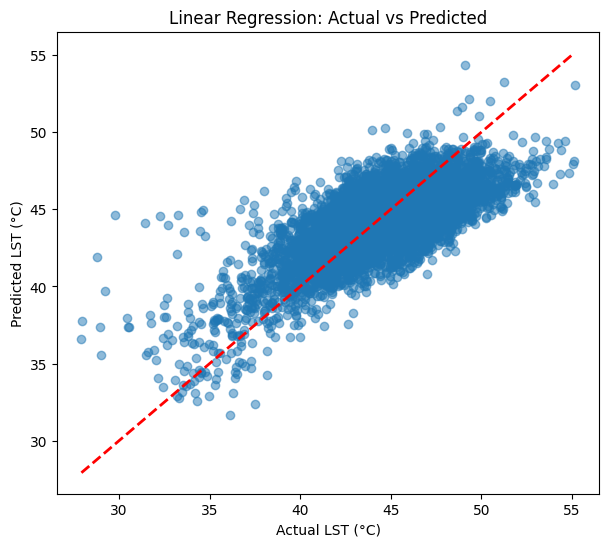

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual LST (°C)")
plt.ylabel("Predicted LST (°C)")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

### Model Interpretation

The Linear Regression model achieved an MAE of **1.565°C**, an RMSE of **2.093°C**, and an R² score of **0.553** on the test dataset.

The model explains approximately **55%** of the variation in Land Surface Temperature (LST). While the prediction accuracy is reasonable, the moderate R² value indicates that a simple linear relationship is insufficient to capture the complex interactions between vegetation, built-up areas, meteorological conditions, and land-cover characteristics.

These results establish a baseline against which more advanced machine learning algorithms will be compared.

## Decision Tree Regressor

Decision Tree Regression is a non-linear machine learning algorithm that predicts the target variable by recursively partitioning the feature space into smaller regions.

Unlike Linear Regression, Decision Trees can capture complex, non-linear relationships between environmental variables and land surface temperature without assuming a linear relationship. This makes them well-suited for modeling urban heat patterns influenced by multiple interacting factors.

Import Libraries

In [82]:
from sklearn.tree import DecisionTreeRegressor

Train the Model

In [83]:
# Initialize the model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

Make Predictions

In [84]:
# Predict on test data
y_pred_dt = dt_model.predict(X_test)

Evaluate the Model

In [85]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-"*35)
print(f"MAE  : {dt_mae:.3f}")
print(f"MSE  : {dt_mse:.3f}")
print(f"RMSE : {dt_rmse:.3f}")
print(f"R² Score : {dt_r2:.4f}")

Decision Tree Performance
-----------------------------------
MAE  : 0.998
MSE  : 1.980
RMSE : 1.407
R² Score : 0.7978


Actual vs Predicted Plot

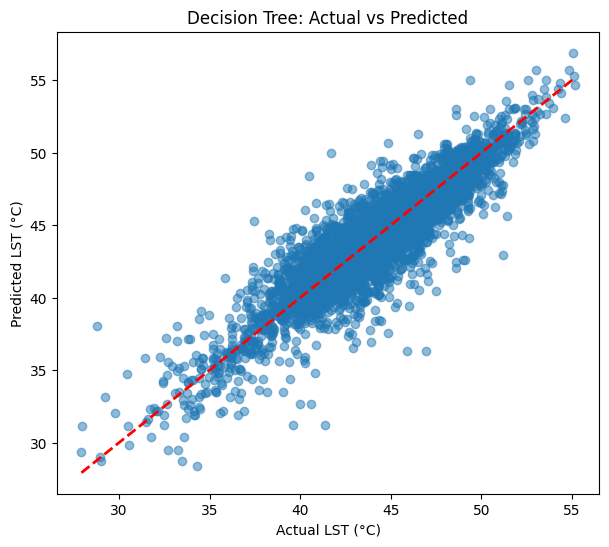

In [86]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_dt, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual LST (°C)")
plt.ylabel("Predicted LST (°C)")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

In [87]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [mae, dt_mae],
    "RMSE": [rmse, dt_rmse],
    "R2 Score": [r2, dt_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.564772,2.092821,0.552811
1,Decision Tree,0.997887,1.407221,0.797813


### Model Interpretation

The Decision Tree Regressor achieved an MAE of **0.998°C**, an RMSE of **1.407°C**, and an R² score of **0.798** on the test dataset.

Compared to the baseline Linear Regression model, the Decision Tree significantly reduced prediction errors and explained approximately **80%** of the variation in Land Surface Temperature.

The improved performance indicates that the relationship between LST and the predictor variables is predominantly non-linear. Decision Trees are able to capture these complex interactions more effectively than linear models.

However, individual Decision Trees are susceptible to overfitting. Therefore, ensemble methods such as Random Forest and Gradient Boosting will be evaluated in the following sections to determine whether prediction accuracy can be further improved.

##  Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve accuracy and reduce overfitting.

Each tree is trained on a random subset of the training data and features. The final prediction is obtained by averaging the predictions from all trees.

Random Forest is widely used for environmental and geospatial regression problems because it effectively models complex, non-linear relationships while providing robust and stable predictions.

Import Library

In [88]:
from sklearn.ensemble import RandomForestRegressor

Train

In [89]:
# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

Predict

In [90]:
y_pred_rf = rf_model.predict(X_test)

Evaluate

In [91]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-"*35)
print(f"MAE  : {rf_mae:.3f}")
print(f"MSE  : {rf_mse:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R² Score : {rf_r2:.4f}")

Random Forest Performance
-----------------------------------
MAE  : 0.719
MSE  : 1.001
RMSE : 1.001
R² Score : 0.8978


In [92]:
results.loc[len(results)] = [
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
]

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.564772,2.092821,0.552811
1,Decision Tree,0.997887,1.407221,0.797813
2,Random Forest,0.719149,1.000599,0.897777


### Model Interpretation

The Random Forest Regressor achieved an MAE of **0.719°C**, an RMSE of **1.001°C**, and an R² score of **0.898** on the test dataset.

Among the models evaluated so far, Random Forest demonstrated the best predictive performance by substantially reducing prediction errors and explaining nearly **90%** of the variation in Land Surface Temperature.

The improved performance is attributed to the ensemble learning approach, where multiple decision trees are combined to produce more accurate and stable predictions while reducing the risk of overfitting.

These results indicate that Random Forest is well-suited for modeling the complex, non-linear relationships between environmental factors and urban surface temperature.

Import Library

In [93]:
from sklearn.ensemble import GradientBoostingRegressor

Train

In [94]:
# Initialize the model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

Predict

In [95]:
y_pred_gb = gb_model.predict(X_test)

Evaluate

In [96]:
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-"*35)
print(f"MAE  : {gb_mae:.3f}")
print(f"MSE  : {gb_mse:.3f}")
print(f"RMSE : {gb_rmse:.3f}")
print(f"R² Score : {gb_r2:.4f}")

Gradient Boosting Performance
-----------------------------------
MAE  : 0.928
MSE  : 1.682
RMSE : 1.297
R² Score : 0.8282


In [97]:
results.loc[len(results)] = [
    "Gradient Boosting",
    gb_mae,
    gb_rmse,
    gb_r2
]

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.564772,2.092821,0.552811
1,Decision Tree,0.997887,1.407221,0.797813
2,Random Forest,0.719149,1.000599,0.897777
3,Gradient Boosting,0.928479,1.297096,0.828220


### Model Interpretation

The Gradient Boosting Regressor achieved an MAE of **0.928°C**, an RMSE of **1.297°C**, and an R² score of **0.828** on the test dataset.

Although Gradient Boosting outperformed the baseline Linear Regression model, its performance was lower than both the Decision Tree and Random Forest models.

These results suggest that, for the current dataset and hyperparameter configuration, Random Forest provides a better balance between predictive accuracy and model generalization. Further hyperparameter tuning could potentially improve the performance of the Gradient Boosting model.

## XGBoost Regressor

Extreme Gradient Boosting (XGBoost) is an optimized ensemble learning algorithm based on gradient boosting. It sequentially builds decision trees while minimizing prediction errors through gradient optimization and regularization techniques.

XGBoost is widely recognized for its high predictive accuracy, computational efficiency, and ability to model complex non-linear relationships. Due to these characteristics, it is commonly used in environmental modeling, geospatial analytics, and machine learning competitions.

In this project, XGBoost is evaluated to determine whether it can further improve the prediction of Land Surface Temperature compared to the previously evaluated models.

Import Library

In [98]:
from xgboost import XGBRegressor

Initialize the Model

In [99]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

Train the Model

In [100]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Make Predictions

In [101]:
y_pred_xgb = xgb_model.predict(X_test)

Evaluate the Model

In [102]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-"*35)
print(f"MAE  : {xgb_mae:.3f}")
print(f"MSE  : {xgb_mse:.3f}")
print(f"RMSE : {xgb_rmse:.3f}")
print(f"R² Score : {xgb_r2:.4f}")

XGBoost Performance
-----------------------------------
MAE  : 0.760
MSE  : 1.092
RMSE : 1.045
R² Score : 0.8885


In [103]:
results.loc[len(results)] = [
    "XGBoost",
    xgb_mae,
    xgb_rmse,
    xgb_r2
]

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.564772,2.092821,0.552811
1,Decision Tree,0.997887,1.407221,0.797813
2,Random Forest,0.719149,1.000599,0.897777
3,Gradient Boosting,0.928479,1.297096,0.828220
4,XGBoost,0.759548,1.045155,0.888471


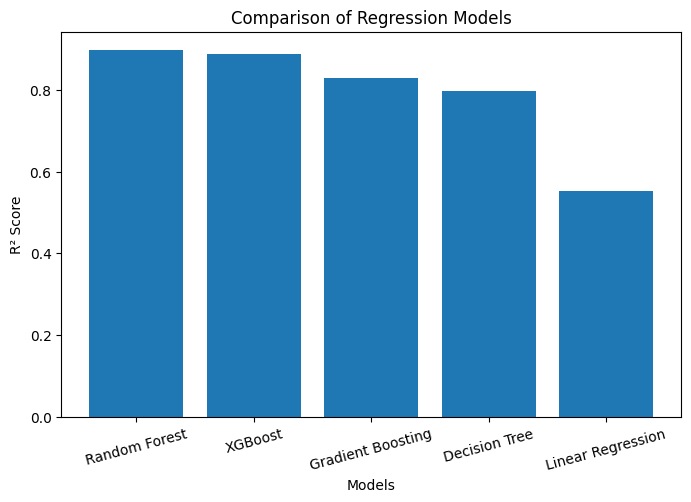

In [104]:
import matplotlib.pyplot as plt

results_sorted = results.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(results_sorted["Model"], results_sorted["R2 Score"])

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models")
plt.xticks(rotation=15)

plt.show()

##  Model Comparison and Selection

Five regression algorithms were evaluated to predict Land Surface Temperature (LST):

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

The models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R² Score).

Among all evaluated models, the Random Forest Regressor achieved the lowest prediction errors and the highest R² score, making it the best-performing model for this study.

### Model Selection

The Random Forest Regressor was selected as the final model for the UltraCool project because it consistently outperformed the other regression algorithms.

The model achieved:

- MAE: **0.719°C**
- RMSE: **1.001°C**
- R² Score: **0.898**

These results indicate that the model explains approximately **90%** of the variation in Land Surface Temperature while maintaining a very low prediction error.

The strong performance demonstrates that ensemble tree-based learning effectively captures the complex non-linear relationships between vegetation, built-up areas, meteorological variables, water bodies, and urban surface temperature.

##  Feature Importance Analysis

Feature importance analysis was performed using the best-performing model, the Random Forest Regressor.

Random Forest estimates the importance of each feature based on its contribution to reducing prediction error across all decision trees in the ensemble.

The analysis helps identify the environmental, spatial, and urban factors that have the greatest influence on Land Surface Temperature (LST). These insights also validate the findings obtained during the Exploratory Data Analysis (EDA).

Extract Feature Names

In [105]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['cat__LULC_Class_Bare_Sparse' 'cat__LULC_Class_Built_Up'
 'cat__LULC_Class_Cropland' 'cat__LULC_Class_Grassland'
 'cat__LULC_Class_Tree_Cover' 'cat__LULC_Class_Unknown'
 'cat__LULC_Class_Water' 'remainder__latitude' 'remainder__longitude'
 'remainder__year' 'remainder__NDVI' 'remainder__NDBI'
 'remainder__AirTemp_C' 'remainder__WindSpeed_ms' 'remainder__Population'
 'remainder__GreenSpace' 'remainder__WaterOccurrence'
 'remainder__WaterBody']


Extract Feature Importance

In [106]:
# Get feature importance scores
importance = rf_model.feature_importances_

 Feature Importance Table

In [107]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
11,remainder__NDBI,0.426958
9,remainder__year,0.228580
8,remainder__longitude,0.105538
16,remainder__WaterOccurrence,0.073247
10,remainder__NDVI,0.050759
7,remainder__latitude,0.048373
14,remainder__Population,0.024865
12,remainder__AirTemp_C,0.020404
13,remainder__WindSpeed_ms,0.013724
2,cat__LULC_Class_Cropland,0.001575


Plot Top 15 Features

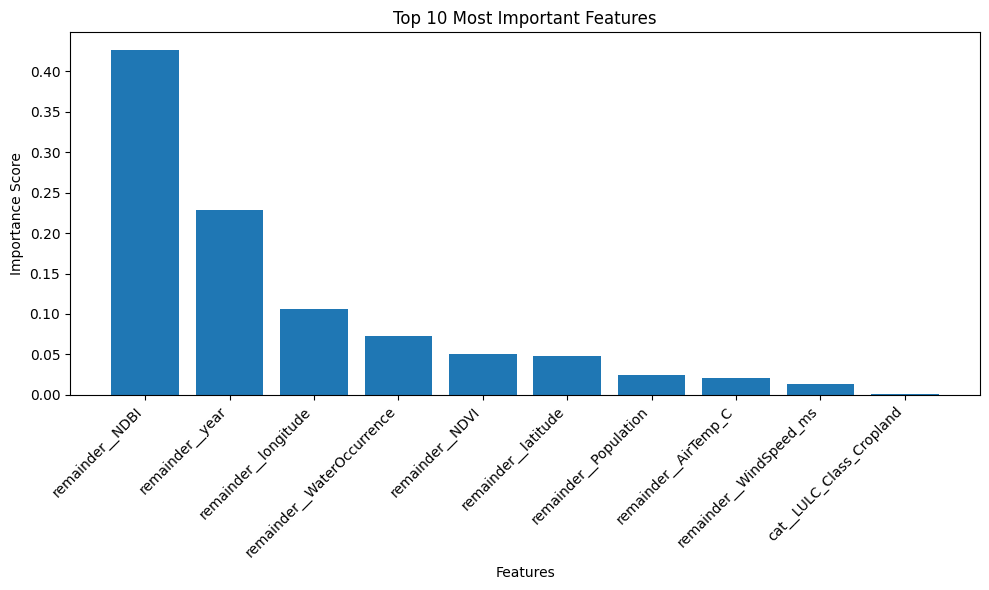

In [109]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Importance Score")
plt.xlabel("Features")

plt.title("Top 10 Most Important Features")

plt.tight_layout()

plt.show()

### Feature Importance Interpretation

The Random Forest model identified **NDBI (Normalized Difference Built-up Index)** as the most influential predictor of Land Surface Temperature, contributing approximately **42.7%** of the total feature importance. This finding indicates that the intensity of built-up surfaces plays a dominant role in determining urban surface temperatures.

The **Year** feature emerged as the second most important predictor, suggesting that temporal variations also have a significant influence on Land Surface Temperature across the study period.

Spatial variables such as **Longitude** and **Latitude** were also important, highlighting the spatial variability of urban heat patterns across Surat.

Among environmental variables, **WaterOccurrence** and **NDVI** were identified as major contributors. Areas with higher vegetation cover and greater water presence generally exhibited lower surface temperatures, supporting the observations made during the exploratory data analysis.

Meteorological variables such as **Air Temperature** and **Wind Speed** contributed less to the predictive model compared to land-cover and spatial characteristics.

Overall, the feature importance analysis demonstrates that built-up intensity, spatial location, vegetation, and water availability are the primary factors influencing Land Surface Temperature within the study area.

# 11.14 Project Conclusion

This project investigated the spatial and temporal patterns of Urban Heat Islands in Surat using environmental, meteorological, land-cover, and socio-economic features.

During the exploratory data analysis, strong relationships were observed between Land Surface Temperature (LST) and vegetation, built-up intensity, water occurrence, and land-cover characteristics. Persistent heat hotspots were identified, and their spatial distribution was analyzed to understand urban heat patterns.

Several regression algorithms were evaluated to predict Land Surface Temperature, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost.

Among all evaluated models, the **Random Forest Regressor** achieved the highest predictive performance with:

- **MAE:** 0.719°C
- **RMSE:** 1.001°C
- **R² Score:** 0.898

Feature importance analysis revealed that **NDBI**, **Year**, **Longitude**, **WaterOccurrence**, and **NDVI** were the most influential predictors of Land Surface Temperature. These findings reinforce the importance of built-up intensity, vegetation, and water resources in shaping urban heat patterns.

Overall, the developed machine learning model provides an effective framework for predicting urban surface temperatures and identifying areas vulnerable to excessive heat. The results can support evidence-based urban planning, green infrastructure development, and sustainable cooling strategies for future cities.

# Future Scope

Although the developed machine learning model demonstrates strong performance in predicting Land Surface Temperature (LST), several enhancements can further improve its accuracy, scalability, and practical applicability.

Future work may include:

- **Real-Time Data Integration:** Incorporate near real-time satellite imagery and weather observations to provide dynamic monitoring and prediction of urban heat patterns.

- **Additional Environmental Features:** Include variables such as rainfall, solar radiation, elevation, air pollution, and building density to better capture the factors influencing urban heat.

- **Application to Multiple Cities:** Extend the proposed framework to other urban regions to evaluate its generalizability and support comparative studies across different climatic and geographical conditions.

- **Advanced Deep Learning Models:** Explore deep learning techniques such as Artificial Neural Networks (ANN), Long Short-Term Memory (LSTM), or Graph Neural Networks (GNN) to model complex spatial and temporal dependencies.

- **Interactive Decision Support System:** Develop a web-based dashboard that visualizes predicted heat hotspots and recommends suitable urban cooling strategies, enabling city planners and policymakers to make informed decisions.

- **Climate Change Assessment:** Use future climate projections to estimate changes in urban heat patterns and evaluate the long-term effectiveness of mitigation strategies.

Overall, these enhancements would improve the predictive capability of the model and increase its value as a decision-support tool for sustainable urban planning and climate-resilient city development.